# 实验六：离散系统中的向下因果验证

目标：
- 用 Rosas et al. (2020) Figure 1 的同款 XOR 最小例子，验证本文向下因果分数 `DC_j` 的计算。
- 补一个混合案例，让式 (5.2) 的 `flexibility` 和 `environment synergy` 同时出现。
- 加入 causal decoupling 对照，说明“整体层有因果结构”不等于“整体对单个节点有向下因果”。
- 为后续神经网络 / Jacobian--Covariance 版本提供一个清晰、可复现的离散基线。


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / 'utils.py').exists():
        candidate_str = str(candidate)
        if candidate_str not in sys.path:
            sys.path.insert(0, candidate_str)
        break
PROJECT_ROOT = candidate

from utils import (
    coarse_grain_output_tpm,
    discrete_downward_causation,
    discrete_downward_causation_all_targets,
    discrete_effective_information,
    render_downward_causation_comparison_svg,
    render_mixed_downward_causation_svg,
    effective_information_from_tpm,
    enumerate_binary_states,
    source_subset_tpm,
)

try:
    from IPython.display import SVG, display
except Exception:  # pragma: no cover - notebook fallback
    SVG = None
    display = print

N_NODES = 3
N_NODES


3

## 实验设计

- **主实验 1**：复现 Rosas Figure 1 右图的最小例子。令 `X_{t+1}^{(1)}` 由整个系统 `X_t` 的 XOR 决定，其余未来节点独立随机。
- **主实验 2**：加入一个混合案例，令 `x1(t+1) = (x1(t) AND x2(t)) XOR x3(t)`，用来同时激活式 (5.2) 的两个组成部分。
- **对照实验**：复现 Figure 1 左图的 causal decoupling 例子。未来整体的 parity 被保持，但任一单个未来节点都不被过去整体单独决定。
- **检验指标**：对每个目标节点 `j` 计算
  `DC_j = EI(X_t -> X_{t+1}^{(j)}) - sum_i EI(X_t^{(i)} -> X_{t+1}^{(j)})`。
- **分解口径**：这里把式 (5.2) 第一项简称为 `flexibility`，把第二项简称为 `environment synergy`。
- **成功标准**：
  - 在 XOR 例子里，被整体 XOR 决定的那个目标节点应有明显正的 `DC_j`，且主要来自 `flexibility`；
  - 在混合案例里，`flexibility` 和 `environment synergy` 都应为正，且典型数值接近 `0.500` 和 `0.311`；
  - 在 causal decoupling 对照里，虽然宏观 parity 有预测力，但所有单节点目标的 `DC_j` 应接近 0。


In [2]:
def build_rosas_downward_causation_tpm(n_nodes: int = 3) -> np.ndarray:
    """Rosas et al. (2020) Example 2: 第 1 个未来节点等于过去整体的 XOR。"""

    states = enumerate_binary_states(n_nodes)
    n_states = len(states)
    tpm = np.zeros((n_states, n_states), dtype=float)

    for row_index, state in enumerate(states):
        parity = int(state.sum() % 2)
        for col_index, next_state in enumerate(states):
            if int(next_state[0]) == parity:
                tpm[row_index, col_index] = 1.0 / (2 ** (n_nodes - 1))

    return tpm


def build_mixed_downward_causation_tpm(n_nodes: int = 3) -> np.ndarray:
    """A mixed 3-node case where flexibility and environment synergy are both positive."""

    states = enumerate_binary_states(n_nodes)
    n_states = len(states)
    tpm = np.zeros((n_states, n_states), dtype=float)

    for row_index, state in enumerate(states):
        x1, x2, x3 = (int(value) for value in state)
        target = int((x1 and x2) ^ x3)
        for col_index, next_state in enumerate(states):
            if int(next_state[0]) == target:
                tpm[row_index, col_index] = 1.0 / (2 ** (n_nodes - 1))

    return tpm


def build_rosas_causal_decoupling_tpm(n_nodes: int = 3) -> np.ndarray:
    """Rosas et al. (2020) Example 1: 未来整体 parity 保持，但单节点没有定向控制。"""

    states = enumerate_binary_states(n_nodes)
    n_states = len(states)
    tpm = np.zeros((n_states, n_states), dtype=float)
    parities = np.array([int(state.sum() % 2) for state in states], dtype=int)

    for row_index, parity in enumerate(parities):
        matching = np.flatnonzero(parities == parity)
        tpm[row_index, matching] = 1.0 / len(matching)

    return tpm


def parity_output_tpm(system_tpm: np.ndarray, n_nodes: int, source_indices: list[int]) -> np.ndarray:
    """把完整未来状态粗粒化成未来 parity 的二值输出。"""

    states = enumerate_binary_states(n_nodes)
    parity_labels = np.array([int(state.sum() % 2) for state in states], dtype=int)
    source_tpm = source_subset_tpm(system_tpm, n_nodes=n_nodes, source_indices=source_indices)
    return coarse_grain_output_tpm(source_tpm, parity_labels)


def round_summary(rows: list[dict], digits: int = 3) -> list[dict]:
    rounded = []
    for row in rows:
        item = {}
        for key, value in row.items():
            if isinstance(value, float):
                item[key] = round(value, digits)
            elif isinstance(value, list):
                item[key] = [round(v, digits) if isinstance(v, float) else v for v in value]
            else:
                item[key] = value
        rounded.append(item)
    return rounded


In [ ]:
# TODO: 重画这两个小例子的图（causal decoupling, downward causation），在风格上错开，避免抄袭嫌疑。后面的Mixed downward causation图也要重画，确保风格统一。

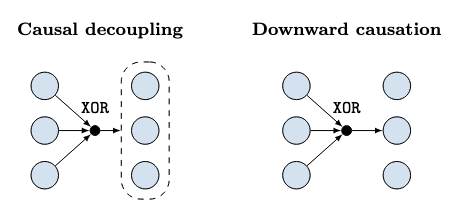

In [3]:
xor_tpm = build_rosas_downward_causation_tpm(n_nodes=N_NODES)
xor_target0 = discrete_downward_causation(xor_tpm, n_nodes=N_NODES, target_index=0)
xor_all_targets = discrete_downward_causation_all_targets(xor_tpm, n_nodes=N_NODES)

xor_checks = {
    'EI(full -> x1_next)': discrete_effective_information(
        xor_tpm,
        n_nodes=N_NODES,
        source_indices=[0, 1, 2],
        target_indices=[0],
    ),
    'EI(x1 -> x1_next)': discrete_effective_information(
        xor_tpm,
        n_nodes=N_NODES,
        source_indices=[0],
        target_indices=[0],
    ),
    'EI(x2 -> x1_next)': discrete_effective_information(
        xor_tpm,
        n_nodes=N_NODES,
        source_indices=[1],
        target_indices=[0],
    ),
    'EI(x3 -> x1_next)': discrete_effective_information(
        xor_tpm,
        n_nodes=N_NODES,
        source_indices=[2],
        target_indices=[0],
    ),
    'DC_1': xor_target0['dc'],
}

print("XOR 例子对目标节点 1 的关键数值：")
for key, value in xor_checks.items():
    print(f"- {key}: {value:.3f}")

print("\n按目标节点汇总的 DC_j：")
round_summary(xor_all_targets)


XOR 例子对目标节点 1 的关键数值：
- EI(full -> x1_next): 1.000
- EI(x1 -> x1_next): 0.000
- EI(x2 -> x1_next): 0.000
- EI(x3 -> x1_next): 0.000
- DC_1: 1.000

按目标节点汇总的 DC_j：


[{'target_index': 0,
  'ei_full': 1.0,
  'ei_singles': [0.0, 0.0, 0.0],
  'self_ei': 0.0,
  'environment_ei': 0.0,
  'joint_term': 1.0,
  'environment_synergy': 0.0,
  'dc': 1.0},
 {'target_index': 1,
  'ei_full': 0.0,
  'ei_singles': [0.0, 0.0, 0.0],
  'self_ei': 0.0,
  'environment_ei': 0.0,
  'joint_term': 0.0,
  'environment_synergy': 0.0,
  'dc': 0.0},
 {'target_index': 2,
  'ei_full': 0.0,
  'ei_singles': [0.0, 0.0, 0.0],
  'self_ei': 0.0,
  'environment_ei': 0.0,
  'joint_term': 0.0,
  'environment_synergy': 0.0,
  'dc': 0.0}]

从上面的结果应当看到：

- `EI(full -> x1_next) = 1 bit`；
- 任一单节点到 `x1_next` 的 EI 都是 0；
- 因而 `DC_1 = 1 bit`；
- 对于另外两个只是随机硬币的目标节点，`DC_j = 0`。

如果把式 (5.2) 的第一项记为 `flexibility`、第二项记为 `environment synergy`，那么这个 Rosas XOR 例子展示的是最纯粹的前者：`flexibility = 1.000`，而 `environment synergy = 0.000`。

这正是本文第 5 节定义想要抓住的东西：**整体对某个个体下一时刻状态的不可约协同作用。**


In [4]:
xor_term_breakdown = {
    'target_index': xor_target0['target_index'],
    'ei_full': xor_target0['ei_full'],
    'self_ei': xor_target0['self_ei'],
    'environment_ei': xor_target0['environment_ei'],
    'flexibility': xor_target0['joint_term'],
    'environment synergy': xor_target0['environment_synergy'],
    'dc': xor_target0['dc'],
}

print("按式 (5.2) 拆开的组成项：")
for key, value in xor_term_breakdown.items():
    if isinstance(value, float):
        print(f"- {key}: {value:.3f}")
    else:
        print(f"- {key}: {value}")


按式 (5.2) 拆开的组成项：
- target_index: 0
- ei_full: 1.000
- self_ei: 0.000
- environment_ei: 0.000
- flexibility: 1.000
- environment synergy: 0.000
- dc: 1.000


## 补充案例：让 flexibility 和 environment synergy 同时出现

这里构造一个最小 3 节点系统，规定

- `x1(t+1) = (x1(t) AND x2(t)) XOR x3(t)`；
- `x2(t+1)` 和 `x3(t+1)` 仍然是独立公平硬币。

这个规则和 Rosas 原始 XOR 例子的区别在于：目标节点既需要个体与环境的联合，也保留了一部分来自环境内部的协同。因此它应同时给出正的 `flexibility` 和正的 `environment synergy`。在这个例子里，典型结果应接近 `flexibility = 0.500`、`environment synergy = 0.311`。


In [5]:
mixed_tpm = build_mixed_downward_causation_tpm(n_nodes=N_NODES)
mixed_target0 = discrete_downward_causation(mixed_tpm, n_nodes=N_NODES, target_index=0)
mixed_all_targets = discrete_downward_causation_all_targets(mixed_tpm, n_nodes=N_NODES)

mixed_checks = {
    'EI(full -> x1_next)': discrete_effective_information(
        mixed_tpm,
        n_nodes=N_NODES,
        source_indices=[0, 1, 2],
        target_indices=[0],
    ),
    'EI(env -> x1_next)': discrete_effective_information(
        mixed_tpm,
        n_nodes=N_NODES,
        source_indices=[1, 2],
        target_indices=[0],
    ),
    'EI(x1 -> x1_next)': discrete_effective_information(
        mixed_tpm,
        n_nodes=N_NODES,
        source_indices=[0],
        target_indices=[0],
    ),
    'EI(x2 -> x1_next)': discrete_effective_information(
        mixed_tpm,
        n_nodes=N_NODES,
        source_indices=[1],
        target_indices=[0],
    ),
    'EI(x3 -> x1_next)': discrete_effective_information(
        mixed_tpm,
        n_nodes=N_NODES,
        source_indices=[2],
        target_indices=[0],
    ),
    'flexibility': mixed_target0['joint_term'],
    'environment synergy': mixed_target0['environment_synergy'],
    'DC_1': mixed_target0['dc'],
}

print("混合案例对目标节点 1 的关键数值：")
for key, value in mixed_checks.items():
    print(f"- {key}: {value:.3f}")

print("\n按目标节点汇总的 DC_j：")
round_summary(mixed_all_targets)


混合案例对目标节点 1 的关键数值：
- EI(full -> x1_next): 1.000
- EI(env -> x1_next): 0.500
- EI(x1 -> x1_next): 0.000
- EI(x2 -> x1_next): 0.000
- EI(x3 -> x1_next): 0.189
- flexibility: 0.500
- environment synergy: 0.311
- DC_1: 0.811

按目标节点汇总的 DC_j：


[{'target_index': 0,
  'ei_full': 1.0,
  'ei_singles': [0.0, 0.0, 0.189],
  'self_ei': 0.0,
  'environment_ei': 0.5,
  'joint_term': 0.5,
  'environment_synergy': 0.311,
  'dc': 0.811},
 {'target_index': 1,
  'ei_full': 0.0,
  'ei_singles': [0.0, 0.0, 0.0],
  'self_ei': 0.0,
  'environment_ei': 0.0,
  'joint_term': 0.0,
  'environment_synergy': 0.0,
  'dc': 0.0},
 {'target_index': 2,
  'ei_full': 0.0,
  'ei_singles': [0.0, 0.0, 0.0],
  'self_ei': 0.0,
  'environment_ei': 0.0,
  'joint_term': 0.0,
  'environment_synergy': 0.0,
  'dc': 0.0}]

这个补充案例的解释重点是：

- `EI(env -> x1_next) = 0.500`，说明环境整体已经能提供一半 bit 的信息；
- 但环境里的两个单元并不等价，其中 `x3` 单独能提供 `0.189` bit，而 `x2` 单独仍为 `0`；
- 因而环境部分还剩下 `0.311` bit 的不可约联合增益，这就是这里的 `environment synergy`；
- 同时，整体到目标的 1 bit 信息也不能被“个体单独 + 环境整体”完全拼出来，所以还保留了 `flexibility = 0.500`。

因此，这个例子正好补上了 Rosas 原始 XOR 案例没有展示出的那一半：**向下因果不仅可以来自个体-环境联合，也可以同时包含环境内部对该个体的协同作用。**


下面把这个 mixed-case 机制画成一张单独的图。和上面的 Rosas 双栏图不同，这张图只服务当前案例：它只保留 `x1,x2` 先经过 `AND`，再与 `x3` 一起经过 `XOR` 的机制结构；相关数值结果直接在正文与研究框架文档中说明，不再写进图里。


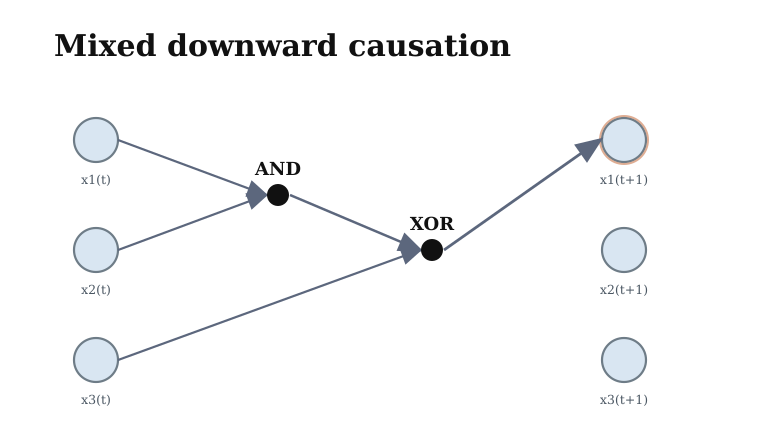

PosixPath('/Users/yangmingzhe/Desktop/code/github/EISyn/fig/experiment6_downward_causation/mixed_downward_causation.svg')

In [6]:
mixed_figure_dir = PROJECT_ROOT / 'fig' / 'experiment6_downward_causation'
mixed_figure_dir.mkdir(parents=True, exist_ok=True)
mixed_figure_path = mixed_figure_dir / 'mixed_downward_causation.svg'

mixed_figure_svg = render_mixed_downward_causation_svg(
    full_ei=mixed_checks['EI(full -> x1_next)'],
    environment_ei=mixed_checks['EI(env -> x1_next)'],
    x3_ei=mixed_checks['EI(x3 -> x1_next)'],
    flexibility=mixed_checks['flexibility'],
    environment_synergy=mixed_checks['environment synergy'],
    dc_value=mixed_checks['DC_1'],
)
mixed_figure_path.write_text(mixed_figure_svg, encoding='utf-8')

if SVG is not None:
    display(SVG(mixed_figure_svg))
mixed_figure_path


## 对照实验：causal decoupling 不等于 downward causation

现在看 Figure 1 左图对应的对照：未来状态会保持过去的 parity，但并不把这份整体层信息压到某一个具体未来节点上。

因此这个系统应表现为：

- 宏观 parity 通道是有信息的；
- 但对任何单个未来节点，`DC_j` 都应接近 0。


In [7]:
decoupling_tpm = build_rosas_causal_decoupling_tpm(n_nodes=N_NODES)
decoupling_all_targets = discrete_downward_causation_all_targets(
    decoupling_tpm,
    n_nodes=N_NODES,
)

parity_full_ei = effective_information_from_tpm(
    parity_output_tpm(decoupling_tpm, n_nodes=N_NODES, source_indices=[0, 1, 2])
)
parity_single_eis = [
    effective_information_from_tpm(
        parity_output_tpm(decoupling_tpm, n_nodes=N_NODES, source_indices=[source])
    )
    for source in range(N_NODES)
]

print("causal decoupling 对照的宏观 parity 通道：")
print(f"- EI(full -> parity_next): {parity_full_ei:.3f}")
for source, value in enumerate(parity_single_eis, start=1):
    print(f"- EI(x{source} -> parity_next): {value:.3f}")

print("\n按目标节点汇总的 DC_j：")
round_summary(decoupling_all_targets)


causal decoupling 对照的宏观 parity 通道：
- EI(full -> parity_next): 1.000
- EI(x1 -> parity_next): 0.000
- EI(x2 -> parity_next): 0.000
- EI(x3 -> parity_next): 0.000

按目标节点汇总的 DC_j：


[{'target_index': 0,
  'ei_full': 0.0,
  'ei_singles': [0.0, 0.0, 0.0],
  'self_ei': 0.0,
  'environment_ei': 0.0,
  'joint_term': 0.0,
  'environment_synergy': 0.0,
  'dc': 0.0},
 {'target_index': 1,
  'ei_full': 0.0,
  'ei_singles': [0.0, 0.0, 0.0],
  'self_ei': 0.0,
  'environment_ei': 0.0,
  'joint_term': 0.0,
  'environment_synergy': 0.0,
  'dc': 0.0},
 {'target_index': 2,
  'ei_full': 0.0,
  'ei_singles': [0.0, 0.0, 0.0],
  'self_ei': 0.0,
  'environment_ei': 0.0,
  'joint_term': 0.0,
  'environment_synergy': 0.0,
  'dc': 0.0}]

这个对照帮助我们区分两种现象：

- **causal decoupling**：整体层变量主要预测另一个整体层变量；
- **downward causation**：整体层变量直接决定某个具体微观目标。

所以，`DC_j` 的正值并不是“只要系统里有整体层信息就会出现”，而是要求这份整体层信息真的压到了某个具体目标节点上。


In [8]:
result = {
    'xor_dc': [row['dc'] for row in xor_all_targets],
    'mixed_dc': [row['dc'] for row in mixed_all_targets],
    'mixed_flexibility': mixed_target0['joint_term'],
    'mixed_environment_synergy': mixed_target0['environment_synergy'],
    'decoupling_dc': [row['dc'] for row in decoupling_all_targets],
    'decoupling_parity_full_ei': parity_full_ei,
}
result


{'xor_dc': [1.0, 0.0, 0.0],
 'mixed_dc': [0.8112781244591328, 0.0, 0.0],
 'mixed_flexibility': 0.5,
 'mixed_environment_synergy': 0.31127812445913283,
 'decoupling_dc': [0.0, 0.0, 0.0],
 'decoupling_parity_full_ei': 1.0}

## Figure-style summary

The following SVG figures redraw the Rosas-style motifs in a cleaner paper figure format.

The mixed case is kept as a separate mechanism sketch, while its numerical decomposition is now explained in the surrounding prose rather than inside the figure itself.

The mixed-case subsection above now exports its own SVG asset: `fig/experiment6_downward_causation/mixed_downward_causation.svg`.


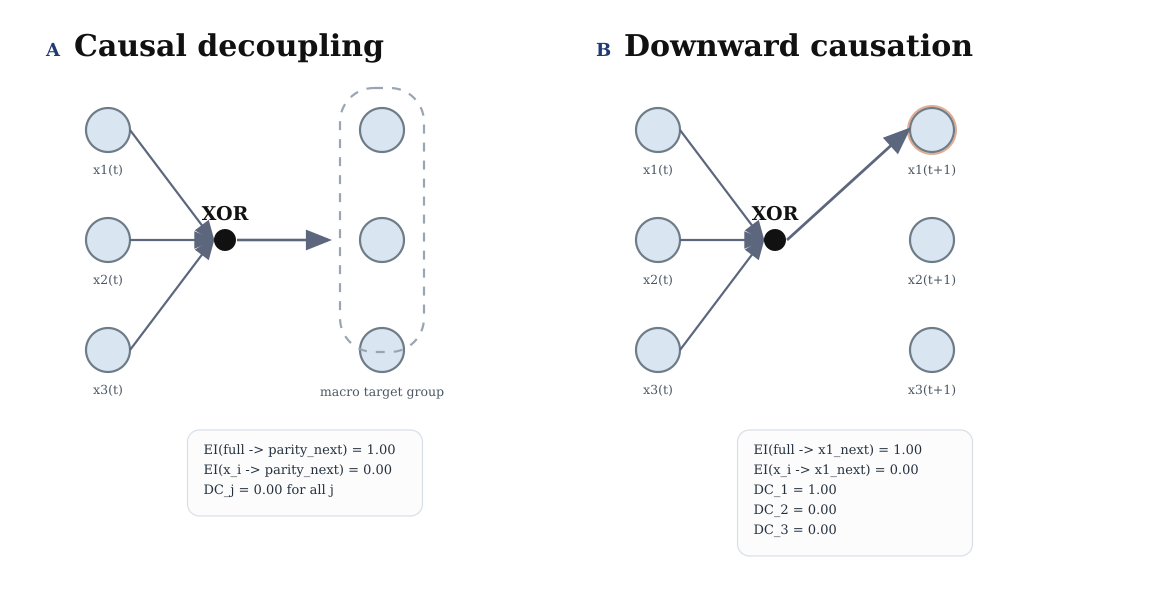

PosixPath('/Users/yangmingzhe/Desktop/code/github/EISyn/fig/experiment6_downward_causation/downward_causation_vs_decoupling.svg')

In [9]:
figure_dir = PROJECT_ROOT / 'fig' / 'experiment6_downward_causation'
figure_dir.mkdir(parents=True, exist_ok=True)
figure_path = figure_dir / 'downward_causation_vs_decoupling.svg'

figure_svg = render_downward_causation_comparison_svg(
    decoupling_parity_ei=parity_full_ei,
    decoupling_single_ei=max(parity_single_eis),
    decoupling_dc_values=result['decoupling_dc'],
    downward_target_ei=xor_checks['EI(full -> x1_next)'],
    downward_single_ei=max([xor_checks['EI(x1 -> x1_next)'], xor_checks['EI(x2 -> x1_next)'], xor_checks['EI(x3 -> x1_next)']]),
    downward_dc_values=result['xor_dc'],
)
figure_path.write_text(figure_svg, encoding='utf-8')

if SVG is not None:
    display(SVG(figure_svg))
figure_path


## 小结与后续扩展

本 notebook 完成了实验六的第一步：先在一个最小、精确、可枚举的离散系统中验证向下因果定义。结论是：

- Rosas XOR 例子中，被整体决定的目标节点显示出显著正的 `DC_j`，而且这个正值完全来自 `flexibility`；
- 新增混合案例 `x1(t+1) = (x1(t) AND x2(t)) XOR x3(t)` 同时给出了正的 `flexibility` 和正的 `environment synergy`；
- causal decoupling 对照虽然保留了宏观 parity 通道，但不会给单节点目标制造假的向下因果。

后续把实验六扩展到神经网络 / Jacobian--Covariance 时，可以继续沿用同一个解释框架：

- 先在潜变量或状态变量层计算 `EI(full -> target_j)`；
- 再减去各单源 `EI(source_i -> target_j)`；
- 然后把 `DC_j` 拆成 `flexibility` 和 `environment synergy`；
- 最后检查这些量是否和消融敏感性、预测误差变化等量相一致。
